## Star-Wars-Survey
### by Ben Murarotto
In this notebook we are handling messy csv data, turning string to boolean, shrinking long form frames and making simple categorical plots.

In [ ]:
import pandas as pd
import numpy as np
csv_path = "StarWars.csv"
df = pd.read_csv(csv_path, encoding="cp1252")
df.head()

,RespondentID,Have you seen any of the 6 films in the Star Wars franchise?,Do you consider yourself to be a fan of the Star Wars film franchise?,Which of the following Star Wars films have you seen? Please select all that apply.,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.,...,Unnamed: 28,Which character shot first?,Are you familiar with the Expanded Universe?,Do you consider yourself to be a fan of the Expanded Universe?Œæ,Do you consider yourself to be a fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
0,NaN,Response,Response,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,Star Wars: Episode I The Phantom Menace,...,Yoda,Response,Response,Response,Response,Response,Response,Response,Response,Response
1,3.292880e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,3,...,Very favorably,I don't understand this question,Yes,No,No,Male,18-29,NaN,High school degree,South Atlantic
2,3.292880e+09,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Yes,Male,18-29,"$0 - $24,999",Bachelor degree,West South Central
3,3.292765e+09,Yes,No,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,NaN,NaN,NaN,1,...,Unfamiliar (N/A),I don't understand this question,No,NaN,No,Male,18-29,"$0 - $24,999",High school degree,West North Central
4,3.292763e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5,...,Very favorably,I don't understand this question,No,NaN,Yes,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central


The first row is a supplement for the headings and the formatting is horrendous so I decided to keep the row for reference in memory and call upon it when we need it to alter column names.

In [213]:
reference_row = df.iloc[0,:]
print(reference_row)
df.drop(index=0)
df = df.reset_index(drop=True)

RespondentID                                                                                                                                                                              NaN
Have you seen any of the 6 films in the Star Wars franchise?                                                                                                                         Response
Do you consider yourself to be a fan of the Star Wars film franchise?                                                                                                                Response
Which of the following Star Wars films have you seen? Please select all that apply.                                                                  Star Wars: Episode I  The Phantom Menace
Unnamed: 4                                                                                                                                        Star Wars: Episode II  Attack of the Clones
Unnamed: 5                                        

Here I am changing the the "Seen Movie X" column to a binary response rather than txt / NaN.
To do this, the notna() function will do exactly what we want, we just have to change the semantics of the column name.

In [214]:
movie_integer_counter = 1
movie_map = {1 : "Phantom Menace (I)", 2 : "Attack of the Clones (II)", 3 : "Revenge of the Sith (III)", 4 : "A New Hope (IV)", 5 : "Empire Strikes Back (V)", 6 : "Return of the Jedi (VI)"}
new_columns = df.columns.tolist()


for col in range(3, 9):
    new_columns[col] = f"Seen {movie_map[movie_integer_counter]}"
    df.iloc[:, col] = df.iloc[:, col].notna()
    movie_integer_counter += 1

df.columns = new_columns
df = df.drop(index=0).reset_index(drop=True)

Similar approach here for the rankings.

In [215]:
movie_integer_counter = 1
new_columns = df.columns.tolist()
for col in range(9, 15):
    new_columns[col] = f"Rank of {movie_map[movie_integer_counter]}"
    df.iloc[:, col] = df.iloc[:, col].astype("Int64")
    movie_integer_counter += 1

df.columns = new_columns
df = df.drop(index=0).reset_index(drop=True)

In [216]:
favourability_ranking = df["Unnamed: 16"].value_counts().index.tolist()
favourability_ranking.remove("Unfamiliar (N/A)")
favourability_ranking

['Very favorably',
 'Somewhat favorably',
 'Neither favorably nor unfavorably (neutral)',
 'Somewhat unfavorably',
 'Very unfavorably']

In [218]:
favourability_order = CategoricalDtype(categories=favourability_ranking, ordered = True)

In [219]:
df.iloc[:,15:29] = df.iloc[:,15:29].replace({"Unfamiliar (N/A)" : np.nan})
for i in range(15, 29):
    df.iloc[:, i] = df.iloc[:, i].astype(favourability_order)

In [220]:
df.head()

,RespondentID,Have you seen any of the 6 films in the Star Wars franchise?,Do you consider yourself to be a fan of the Star Wars film franchise?,Seen Phantom Menace (I),Seen Attack of the Clones (II),Seen Revenge of the Sith (III),Seen A New Hope (IV),Seen Empire Strikes Back (V),Seen Return of the Jedi (VI),Rank of Phantom Menace (I),...,Unnamed: 28,Which character shot first?,Are you familiar with the Expanded Universe?,Do you consider yourself to be a fan of the Expanded Universe?Œæ,Do you consider yourself to be a fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
0,3.292880e+09,No,NaN,False,False,False,False,False,False,<NA>,...,NaN,NaN,NaN,NaN,Yes,Male,18-29,"$0 - $24,999",Bachelor degree,West South Central
1,3.292765e+09,Yes,No,True,True,True,False,False,False,1,...,NaN,I don't understand this question,No,NaN,No,Male,18-29,"$0 - $24,999",High school degree,West North Central
2,3.292763e+09,Yes,Yes,True,True,True,True,True,True,5,...,Very favorably,I don't understand this question,No,NaN,Yes,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
3,3.292731e+09,Yes,Yes,True,True,True,True,True,True,5,...,Somewhat favorably,Greedo,Yes,No,No,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
4,3.292719e+09,Yes,Yes,True,True,True,True,True,True,1,...,Very favorably,Han,Yes,No,Yes,Male,18-29,"$25,000 - $49,999",Bachelor degree,Middle Atlantic


In [221]:
new_columns = df.columns.tolist()
targets = new_columns[15:29]
counter = 15

# print(targets)

for col in targets:
        char = reference_row.iloc[counter]
        new_columns[counter] = f"Feelings on: {char}"
        counter += 1
        print(char)

df.columns = new_columns

df.head()
        

Han Solo
Luke Skywalker
Princess Leia Organa
Anakin Skywalker
Obi Wan Kenobi
Emperor Palpatine
Darth Vader
Lando Calrissian
Boba Fett
C-3P0
R2 D2
Jar Jar Binks
Padme Amidala
Yoda


,RespondentID,Have you seen any of the 6 films in the Star Wars franchise?,Do you consider yourself to be a fan of the Star Wars film franchise?,Seen Phantom Menace (I),Seen Attack of the Clones (II),Seen Revenge of the Sith (III),Seen A New Hope (IV),Seen Empire Strikes Back (V),Seen Return of the Jedi (VI),Rank of Phantom Menace (I),...,Feelings on: Yoda,Which character shot first?,Are you familiar with the Expanded Universe?,Do you consider yourself to be a fan of the Expanded Universe?Œæ,Do you consider yourself to be a fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
0,3.292880e+09,No,NaN,False,False,False,False,False,False,<NA>,...,NaN,NaN,NaN,NaN,Yes,Male,18-29,"$0 - $24,999",Bachelor degree,West South Central
1,3.292765e+09,Yes,No,True,True,True,False,False,False,1,...,NaN,I don't understand this question,No,NaN,No,Male,18-29,"$0 - $24,999",High school degree,West North Central
2,3.292763e+09,Yes,Yes,True,True,True,True,True,True,5,...,Very favorably,I don't understand this question,No,NaN,Yes,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
3,3.292731e+09,Yes,Yes,True,True,True,True,True,True,5,...,Somewhat favorably,Greedo,Yes,No,No,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
4,3.292719e+09,Yes,Yes,True,True,True,True,True,True,1,...,Very favorably,Han,Yes,No,Yes,Male,18-29,"$25,000 - $49,999",Bachelor degree,Middle Atlantic


In [222]:
for i in range(30,33):
    df.iloc[:,i] = df.iloc[:, i].replace({"Yes" : True, "No" : False})

Time to check the final categorical values then make some plots.

In [224]:
df["Gender"].value_counts()

Gender
Female    549
Male      496
Name: count, dtype: int64

In [225]:
income = ['$0 - $24,999', '$25,000 - $49,999', '$50,000 - $99,999', '$100,000 - $149,999', '$150,000+']
income_rankings = CategoricalDtype(categories= income, ordered=True)

df["Household Income"] = df["Household Income"].astype(income_rankings)
df["Household Income"]

0              $0 - $24,999
1              $0 - $24,999
2       $100,000 - $149,999
3       $100,000 - $149,999
4         $25,000 - $49,999
               ...         
1180           $0 - $24,999
1181      $50,000 - $99,999
1182      $50,000 - $99,999
1183    $100,000 - $149,999
1184      $50,000 - $99,999
Name: Household Income, Length: 1185, dtype: category
Categories (5, object): ['$0 - $24,999' < '$25,000 - $49,999' < '$50,000 - $99,999' < '$100,000 - $149,999' < '$150,000+']

In [226]:
education = ['Less than high school degree', 'High school degree', 'Some college or Associate degree', 'Bachelor degree', 'Graduate degree']
education_ranking = CategoricalDtype(categories=education, ordered=True)
df["Education"] = df["Education"].astype(education_ranking)
df["Education"]


0                        Bachelor degree
1                     High school degree
2       Some college or Associate degree
3       Some college or Associate degree
4                        Bachelor degree
                      ...               
1180    Some college or Associate degree
1181                     Bachelor degree
1182                     Bachelor degree
1183    Some college or Associate degree
1184                     Graduate degree
Name: Education, Length: 1185, dtype: category
Categories (5, object): ['Less than high school degree' < 'High school degree' < 'Some college or Associate degree' < 'Bachelor degree' < 'Graduate degree']

In [ ]:
df_rankings = df.iloc[:, 9:15]
number_1_movie_counts = []

for col in df_rankings.columns:
    one_counts = df[col].eq(1).sum()
    number_1_movie_counts.append(one_counts)

print(number_1_movie_counts)

[np.int64(129), np.int64(32), np.int64(35), np.int64(204), np.int64(289), np.int64(146)]


In [228]:
df_seen = df.iloc[:, 3:9]
number_seen_counts = []

for col in df_seen.columns:
    yes_counts = df_seen[col].eq(True).sum()
    number_seen_counts.append(yes_counts)

print(number_seen_counts)

[np.int64(672), np.int64(570), np.int64(549), np.int64(606), np.int64(757), np.int64(737)]


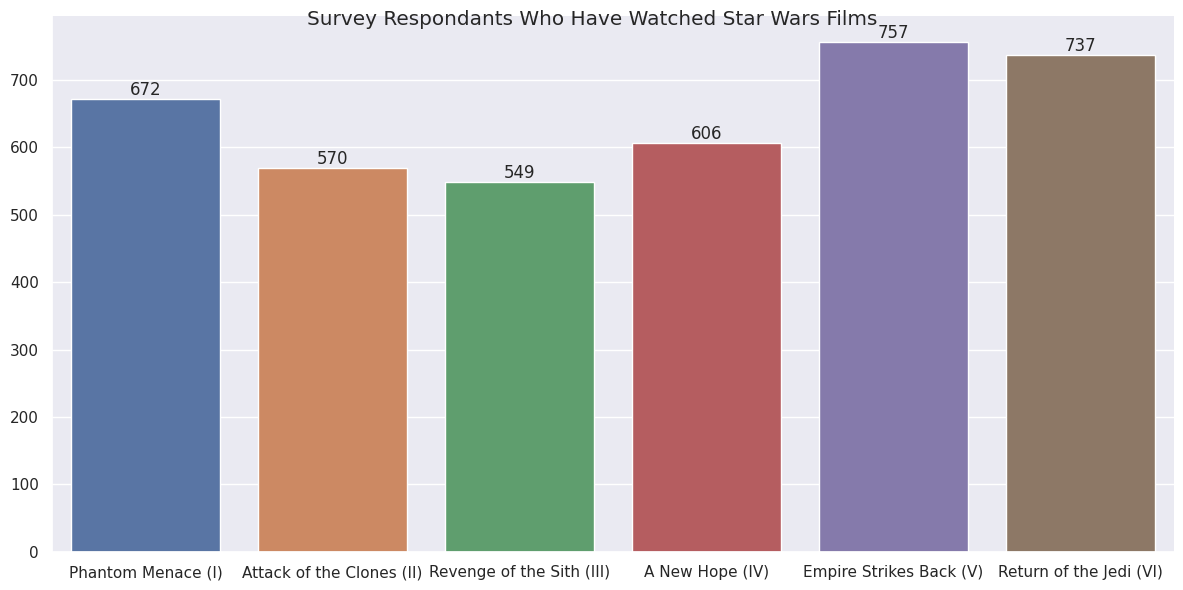

In [229]:
import seaborn as sns
sns.set_theme()

films = list(movie_map.values())

g = sns.catplot(kind = "bar", x = films, 
y = number_seen_counts, 
height = 6, 
aspect = 2,
hue = films
)
g.figure.suptitle("Survey Respondants Who Have Watched Star Wars Films")
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)

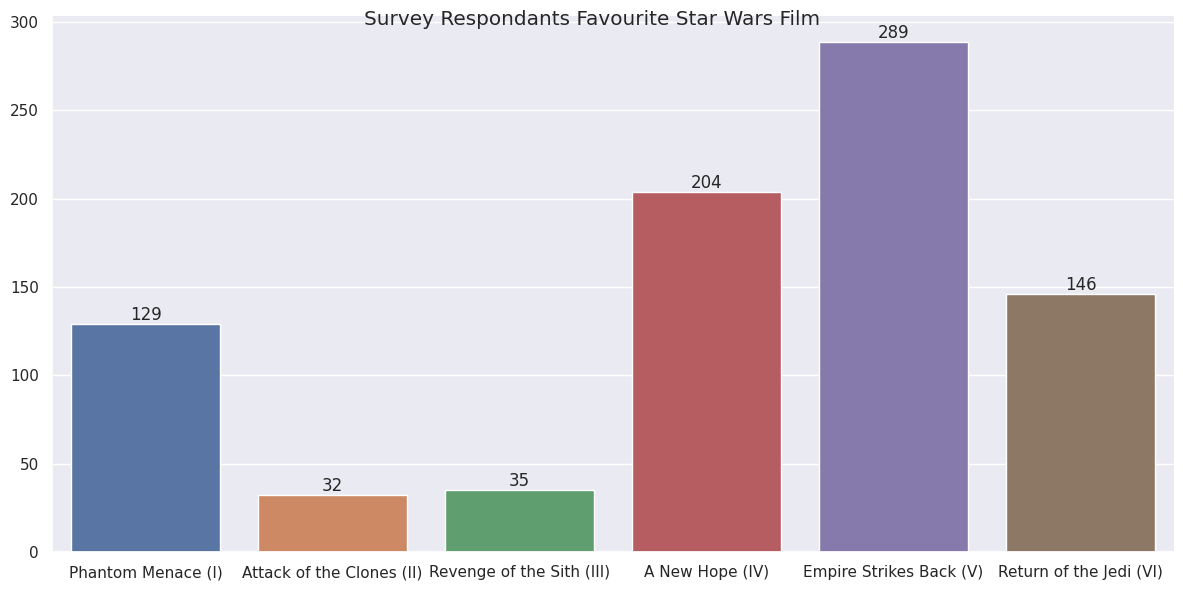

In [ ]:
g = sns.catplot(kind = "bar", x = films, 
y = number_1_movie_counts, 
height = 6, 
aspect = 2,
hue = films
)
g.figure.suptitle("Survey Respondants Favourite Star Wars Film")
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)

Now we need to split counts by gender.

In [231]:
seen_cols = [f"Seen {movie_map[i]}" for i in range(1, 7)]
counts_by_gender = df.groupby("Gender")[seen_cols].sum()
counts_by_gender

,Seen Phantom Menace (I),Seen Attack of the Clones (II),Seen Revenge of the Sith (III),Seen A New Hope (IV),Seen Empire Strikes Back (V),Seen Return of the Jedi (VI)
Gender,,,,,,
Female,298,237,222,255,353,338
Male,360,322,316,341,391,386


In [232]:
counts_long = counts_by_gender.reset_index().melt(
    id_vars="Gender", value_vars=seen_cols, var_name="Film", value_name="Count"
)
counts_long["Film"] = counts_long["Film"].str.replace("Seen ", "", regex=False)
counts_long

,Gender,Film,Count
0,Female,Phantom Menace (I),298
1,Male,Phantom Menace (I),360
2,Female,Attack of the Clones (II),237
3,Male,Attack of the Clones (II),322
4,Female,Revenge of the Sith (III),222
5,Male,Revenge of the Sith (III),316
6,Female,A New Hope (IV),255
7,Male,A New Hope (IV),341
8,Female,Empire Strikes Back (V),353
9,Male,Empire Strikes Back (V),391


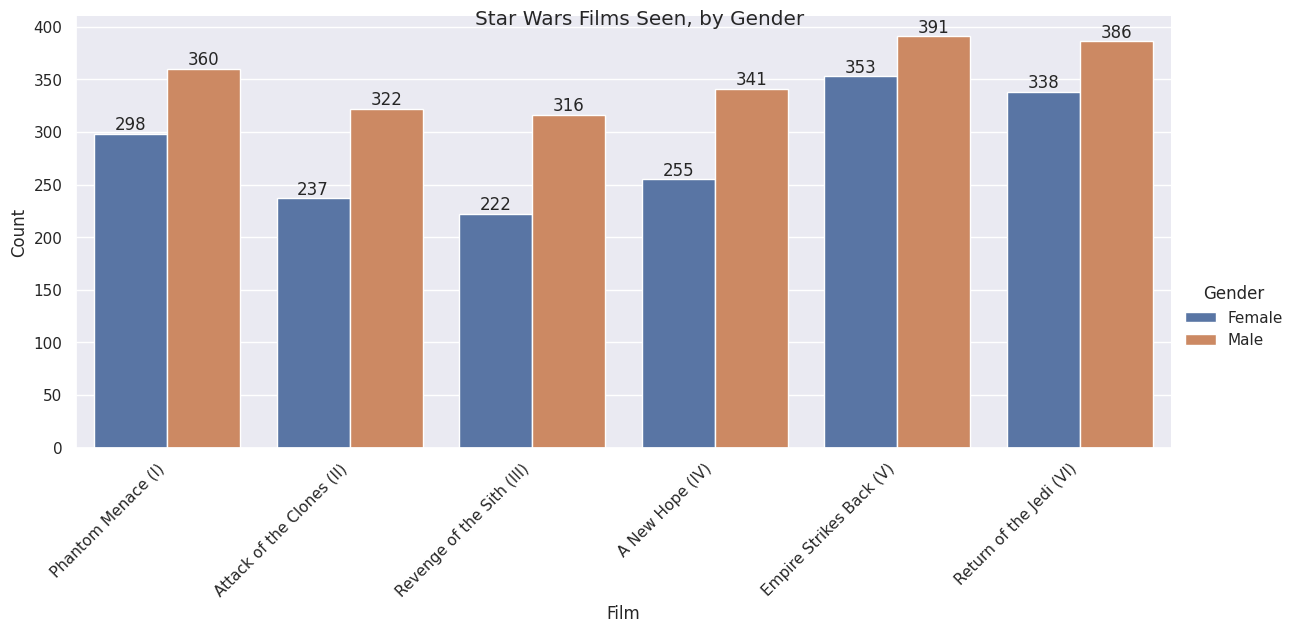

In [233]:
g = sns.catplot(
    data=counts_long, x="Film", y="Count", hue="Gender",
    kind="bar", height=6, aspect=2
)
g.figure.suptitle("Star Wars Films Seen, by Gender")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    for container in ax.containers:
        ax.bar_label(container)
g.figure.subplots_adjust(bottom=0.25)

In [ ]:
for i in range (1, 7):
    df[f"Favourite Film {movie_map[i]}"] = df_rankings.iloc[:,i-1].eq(1)


,RespondentID,Have you seen any of the 6 films in the Star Wars franchise?,Do you consider yourself to be a fan of the Star Wars film franchise?,Seen Phantom Menace (I),Seen Attack of the Clones (II),Seen Revenge of the Sith (III),Seen A New Hope (IV),Seen Empire Strikes Back (V),Seen Return of the Jedi (VI),Rank of Phantom Menace (I),...,Age,Household Income,Education,Location (Census Region),Favourite Film Phantom Menace (I),Favourite Film Attack of the Clones (II),Favourite Film Revenge of the Sith (III),Favourite Film A New Hope (IV),Favourite Film Empire Strikes Back (V),Favourite Film Return of the Jedi (VI)
0,3.292880e+09,No,NaN,False,False,False,False,False,False,<NA>,...,18-29,"$0 - $24,999",Bachelor degree,West South Central,False,False,False,False,False,False
1,3.292765e+09,Yes,No,True,True,True,False,False,False,1,...,18-29,"$0 - $24,999",High school degree,West North Central,True,False,False,False,False,False
2,3.292763e+09,Yes,Yes,True,True,True,True,True,True,5,...,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central,False,False,True,False,False,False
3,3.292731e+09,Yes,Yes,True,True,True,True,True,True,5,...,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central,False,False,False,False,True,False
4,3.292719e+09,Yes,Yes,True,True,True,True,True,True,1,...,18-29,"$25,000 - $49,999",Bachelor degree,Middle Atlantic,True,False,False,False,False,False


In [263]:
fav_cols = df.columns[38:45]
fav_by_gender = df.groupby("Gender")[fav_cols].sum()

fav_long = fav_by_gender.reset_index().melt(
    id_vars = "Gender",
    value_vars = fav_cols,
    var_name="Film", 
    value_name="Count"
)
fav_long["Film"] = fav_long["Film"].str.replace("Favourite Film ", "", regex=False)

fav_long

,Gender,Film,Count
0,Female,Phantom Menace (I),65
1,Male,Phantom Menace (I),58
2,Female,Attack of the Clones (II),17
3,Male,Attack of the Clones (II),15
4,Female,Revenge of the Sith (III),17
5,Male,Revenge of the Sith (III),18
6,Female,A New Hope (IV),90
7,Male,A New Hope (IV),112
8,Female,Empire Strikes Back (V),131
9,Male,Empire Strikes Back (V),152


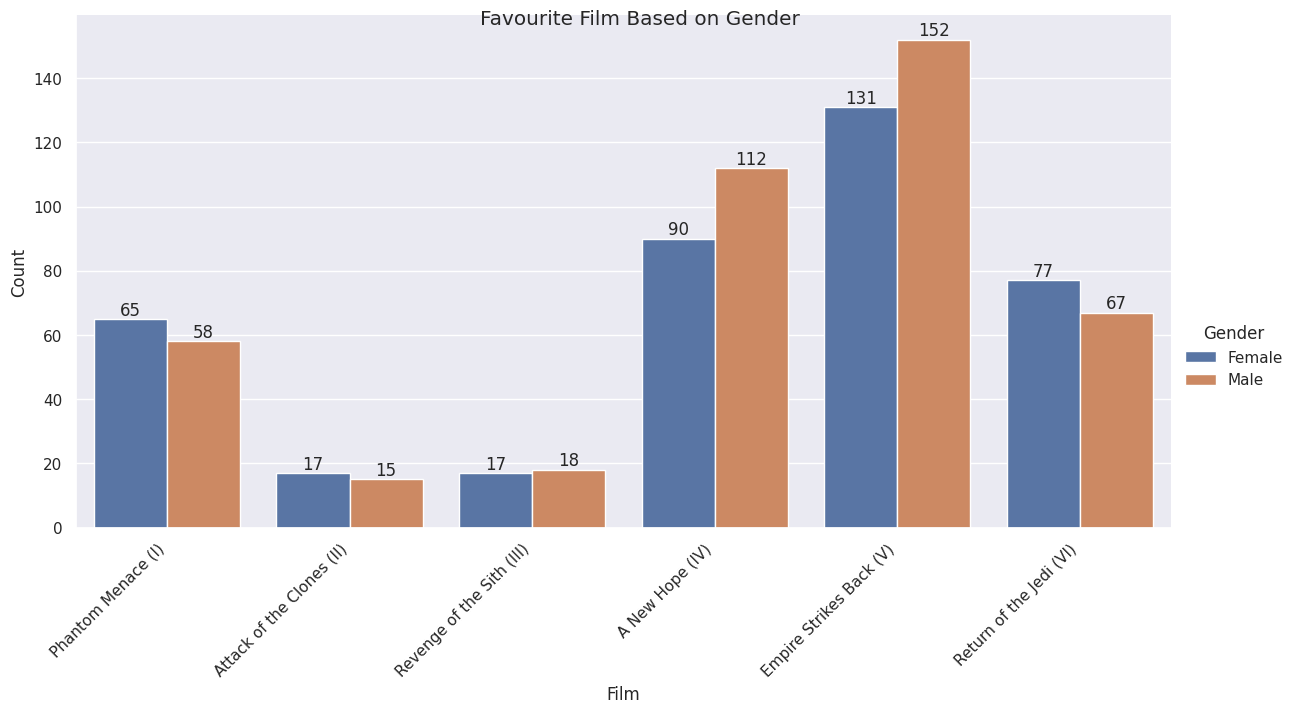

In [ ]:
g = sns.catplot(data=fav_long,
kind = "bar",
x = "Film",
y = "Count",
hue = "Gender",
height= 6,
aspect = 2)
g.figure.suptitle("Favourite Film Based on Gender")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    for container in ax.containers:
        ax.bar_label(container)

Now we can settle the Han vs Greedo debate simply by checking value counts.

In [301]:
who_shot = df["Which character shot first?"].value_counts()
who_shot = who_shot.drop("I don't understand this question")
who_shot

Which character shot first?
Han       325
Greedo    197
Name: count, dtype: int64

Text(0.5, 1.0, 'Who Shot First?')

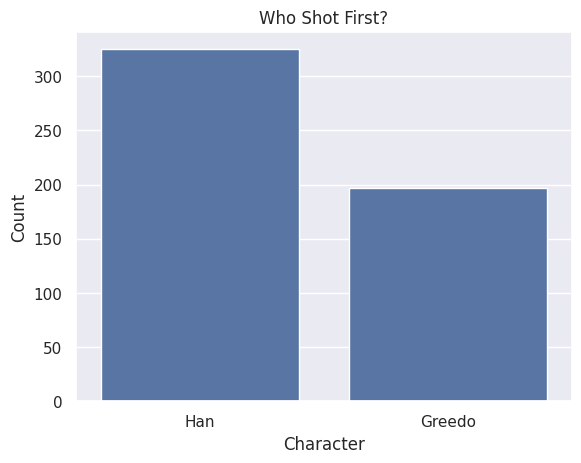

In [307]:
g = sns.barplot(x=who_shot.index, y = who_shot.values)
g.set_xlabel("Character")
g.set_ylabel("Count")
g.set_title("Who Shot First?")